In [1]:
import pandas as pd
from jiwer import wer, cer
from utils.num_to_words import numbers_to_words
import re
import evaluate

/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
def clean_text(text):
    text = re.sub(r"-", " ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = text.lower()
    return text

comet = evaluate.load('comet')

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 67650.06it/s]
Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.1.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../../../../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [3]:
speakers = [
    "speaker_1", "speaker_2", "speaker_3", "speaker_4", "speaker_5",
    "speaker_6", "speaker_7", "speaker_8", "speaker_9", "speaker_10"
]

chunk_sizes = [3000, 3500, 4000, 4500, 5000, 5500, 6000]

## Data preprocessing 

In [ ]:
df = pd.DataFrame(columns=['language','chunk_size', 'speaker', 'wer', 'cer', 'comet-score', 'stt_time', 'tt_time', 'tts_time', 'total_time'])

# # Danish
# for size in chunk_sizes:
#     for speaker in speakers:
#         # Loading data
#         csv_df = pd.read_csv(f'logs/dk_{speaker}_chunk{size}.csv')

#         model_transcription = ' '.join(csv_df['transcription'].astype(str))
#         model_translation = ' '.join(csv_df['translation'].astype(str))

#         with open(f"data/danish/dk_{speaker}_final.txt", "r", encoding="utf-8") as f:
#             ref_transcription = f.read()
#         with open(f"data/english/{speaker}_final.txt", "r", encoding="utf-8") as f:
#             ref_translation = f.read()

#         # Cleaning data
#         model_transcription = clean_text(model_transcription)
#         model_transcription = numbers_to_words(model_transcription, 'da', split_abbreviations=False)
#         model_transcription = model_transcription.replace(' øøhhm', '')

#         model_translation = clean_text(model_translation)
#         model_translation = numbers_to_words(model_translation, 'en', split_abbreviations=False)
#         model_translation = model_translation.replace(' ohhm', '')

#         ref_transcription = clean_text(ref_transcription)
#         ref_transcription = numbers_to_words(ref_transcription, 'da')

#         ref_translation = clean_text(ref_translation)
#         ref_translation = numbers_to_words(ref_transcription)

#         # Computing metrics
#         wer_score = wer(reference=ref_transcription, hypothesis=model_transcription)
#         cer_score = cer(reference=ref_transcription, hypothesis=model_transcription)

#         comet_score = comet.compute(predictions=[model_translation], references=[ref_transcription], sources=[model_transcription])['score'][0]

#         stt_times = csv_df['stt_latency_ms'].tolist()
#         tt_times = csv_df['tt_latency_ms'].tolist()
#         tts_times = csv_df['tts_latency_ms'].tolist()
#         total_times = csv_df['total_latency_ms'].tolist()

#         df.loc[len(df)] = ['da', size, speaker, wer_score, comet_score, stt_times, tt_times, tts_times, total_times]

# English
# for size in chunk_sizes:
#     for speaker in speakers:
#         # Loading data
#         csv_df = pd.read_csv(f'logs/{speaker}_final_chunk{size}.csv')

#         model_transcription = ' '.join(csv_df['transcription'].astype(str))
#         model_translation = ' '.join(csv_df['translation'].astype(str))

#         with open(f"data/english/{speaker}_final.txt", "r", encoding="utf-8") as f:
#             ref_transcription = f.read()
#         with open(f"data/danish/dk_{speaker}_final.txt", "r", encoding="utf-8") as f:
#             ref_translation = f.read()

#         # Cleaning data
#         model_transcription = clean_text(model_transcription)
#         model_transcription = numbers_to_words(model_transcription, 'en', split_abbreviations=False)

#         model_translation = clean_text(model_translation)
#         model_translation = numbers_to_words(model_translation, 'da', split_abbreviations=False)

#         ref_transcription = clean_text(ref_transcription)
#         ref_transcription = numbers_to_words(ref_transcription, 'en', split_abbreviations=False)

#         ref_translation = clean_text(ref_translation)
#         ref_translation = numbers_to_words(ref_transcription, 'da', split_abbreviations=False)

#         # Computing metrics
#         print('ref_transcription: ', ref_transcription)
#         print('hypothesis_transcription: ', model_transcription)
#         wer_score = wer(reference=ref_transcription, hypothesis=model_transcription)
#         cer_score = cer(reference=ref_transcription, hypothesis=model_transcription)

#         comet_score = comet.compute(predictions=[model_translation], references=[ref_transcription], sources=[model_transcription])['score'][0]

#         stt_times = csv_df['stt_latency_ms'].tolist()
#         tt_times = csv_df['tt_latency_ms'].tolist()
#         tts_times = csv_df['tts_latency_ms'].tolist()
#         total_times = csv_df['total_latency_ms'].tolist()

#         df.loc[len(df)] = ['en', size, speaker, wer_score, cer_score, comet_score, stt_times, tt_times, tts_times, total_times]

# df.to_csv('results.csv')

In [21]:
from comet import download_model, load_from_checkpoint

# Load COMET model once
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

df = pd.DataFrame(columns=['language','chunk_size', 'speaker', 'wer', 'cer', 'comet-score', 'stt_time', 'tt_time', 'tts_time', 'total_time'])


def data_results(input_language, output_language):
    for size in chunk_sizes:
        for speaker in speakers:
            # Load data
            if input_language == 'en':
                csv_df = pd.read_csv(f'logs/{speaker}_final_chunk{size}.csv')
            if input_language == 'da':
                csv_df = pd.read_csv(f'logs/dk_{speaker}_chunk{size}.csv')


            model_transcription = ' '.join(csv_df['transcription'].astype(str))
            model_translation = ' '.join(csv_df['translation'].astype(str))

            if input_language == 'en':
                with open(f"data/english/{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_transcription = f.read()
                with open(f"data/danish/dk_{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_translation = f.read()

            if input_language == 'da':
                with open(f"data/danish/dk_{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_transcription = f.read()
                with open(f"data/english/{speaker}_final.txt", "r", encoding="utf-8") as f:
                    ref_translation = f.read()


            # Clean and normalize text
            model_transcription = clean_text(model_transcription)
            model_transcription = numbers_to_words(model_transcription, input_language, split_abbreviations=False)

            model_translation = clean_text(model_translation)
            model_translation = numbers_to_words(model_translation, output_language, split_abbreviations=False)

            ref_transcription = clean_text(ref_transcription)
            ref_transcription = numbers_to_words(ref_transcription, input_language, split_abbreviations=False)

            ref_translation = clean_text(ref_translation)
            ref_translation = numbers_to_words(ref_translation, output_language, split_abbreviations=False)

            # Compute WER and CER
            wer_score = wer(reference=ref_transcription, hypothesis=model_transcription)
            cer_score = cer(reference=ref_transcription, hypothesis=model_transcription)

            # Compute COMET score using direct model
            data = [{
                "src": model_transcription,
                "mt": model_translation,
                "ref": ref_transcription
            }]
            comet_score = comet_model.predict(data, batch_size=1, gpus=0, num_workers=1).scores[0]

            # Collect latency metrics
            stt_times = csv_df['stt_latency_ms'].tolist()
            tt_times = csv_df['tt_latency_ms'].tolist()
            tts_times = csv_df['tts_latency_ms'].tolist()
            total_times = csv_df['total_latency_ms'].tolist()

            # Append row to DataFrame
            df.loc[len(df)] = [
                input_language, size, speaker, wer_score, cer_score, comet_score,
                stt_times, tt_times, tts_times, total_times
            ]

    # Save results
    df.to_csv(f'results_{input_language}.csv', index=False)



Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 69212.94it/s]
Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.1.post0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../../../../../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [22]:
data_results('en', 'da')

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
python(41586) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:01<00:00,  1.79s/it]
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/claralouisebrodt/anaconda3/envs/02466_AI_dubbing/lib/python3.12/site-

In [26]:
data_results('da', 'en')

FileNotFoundError: [Errno 2] No such file or directory: 'logs/dk_speaker_1_chunk3000.csv'

## data vizualisation

In [25]:
df_en = pd.read_csv("results_en.csv")

df_en


,language,chunk_size,speaker,wer,cer,comet-score,stt_time,tt_time,tts_time,total_time
0,en,3000,speaker_1,0.181435,0.110599,0.523323,"[554.3, 611.49, 509.93, 639.52, 624.08, 572.07...","[694.31, 1089.04, 1080.62, 1317.73, 1373.31, 1...","[7205.89, 8885.2, 3010.32, 6003.2, 3927.24, 39...","[10530.53, 15739.96, 15688.94, 18623.27, 19284..."
1,en,3000,speaker_2,0.131034,0.101217,0.603140,"[544.36, 561.61, 555.64, 498.61, 524.69, 497.5...","[476.26, 784.63, 900.63, 881.02, 923.07, 884.4...","[4054.19, 6054.14, 4610.48, 2615.34, 2978.01, ...","[8270.88, 11264.67, 12605.6, 12159.73, 12072.3..."
2,en,3000,speaker_3,0.198083,0.143213,0.550716,"[558.4, 519.07, 514.12, 538.12, 490.56, 497.08...","[727.62, 772.61, 678.11, 1033.21, 1126.5, 895....","[6386.0, 1804.25, 1916.13, 5164.65, 2530.59, 2...","[11092.16, 9421.43, 8268.52, 9959.53, 9233.58,..."
3,en,3000,speaker_4,0.190332,0.126032,0.558501,"[521.41, 550.56, 542.26, 572.91, 543.32, 593.7...","[547.11, 921.2, 823.63, 913.26, 827.54, 722.55...","[5461.21, 6097.7, 2769.59, 3392.59, 2698.77, 2...","[9617.9, 12660.97, 12365.58, 12688.38, 12323.2..."
4,en,3000,speaker_5,0.104000,0.094545,0.614461,"[548.61, 510.72, 578.07, 534.65, 468.39, 598.2...","[550.06, 896.12, 1090.94, 1106.13, 798.83, 878...","[7222.31, 4760.31, 6324.65, 2808.94, 2471.99, ...","[11826.78, 13477.54, 16684.77, 16161.79, 15525..."
...,...,...,...,...,...,...,...,...,...,...
65,en,6000,speaker_6,0.086076,0.059838,0.665034,"[676.5, 2138.17, 642.77, 616.61, 802.42, 709.7...","[1478.59, 1871.29, 1879.39, 1683.12, 2257.84, ...","[19868.4, 9073.94, 6022.15, 5796.23, 7502.3, 6...","[22100.78, 24925.04, 24725.2, 23670.21, 24959...."
66,en,6000,speaker_7,0.118497,0.094170,0.606331,"[616.58, 627.01, 576.2, 609.6, 681.35, 552.88,...","[1416.96, 1609.15, 1391.97, 1489.58, 1682.63, ...","[14551.11, 5223.85, 3450.81, 4643.72, 8876.41,...","[16585.58, 15571.58, 12368.94, 10803.49, 13308..."
67,en,6000,speaker_8,0.151429,0.122620,0.663191,"[624.81, 615.08, 680.71, 616.62, 575.73, 640.7...","[1662.73, 1546.33, 1311.63, 1441.69, 1185.35, ...","[15800.28, 4633.71, 4885.36, 5015.5, 3737.44, ...","[18089.33, 16504.51, 15154.15, 13787.92, 11347..."
68,en,6000,speaker_9,0.146667,0.113439,0.591600,"[758.87, 743.38, 767.1, 631.06, 717.56, 688.59...","[1314.18, 1949.41, 2141.76, 2011.26, 1946.28, ...","[18462.09, 5626.2, 19885.05, 4772.23, 8045.91,...","[20536.34, 19915.44, 33341.29, 31234.06, 33102..."


In [15]:

import seaborn as sns
import ast
import matplotlib.pyplot as plt


## Plot for each STT, TT, TTS showing each author

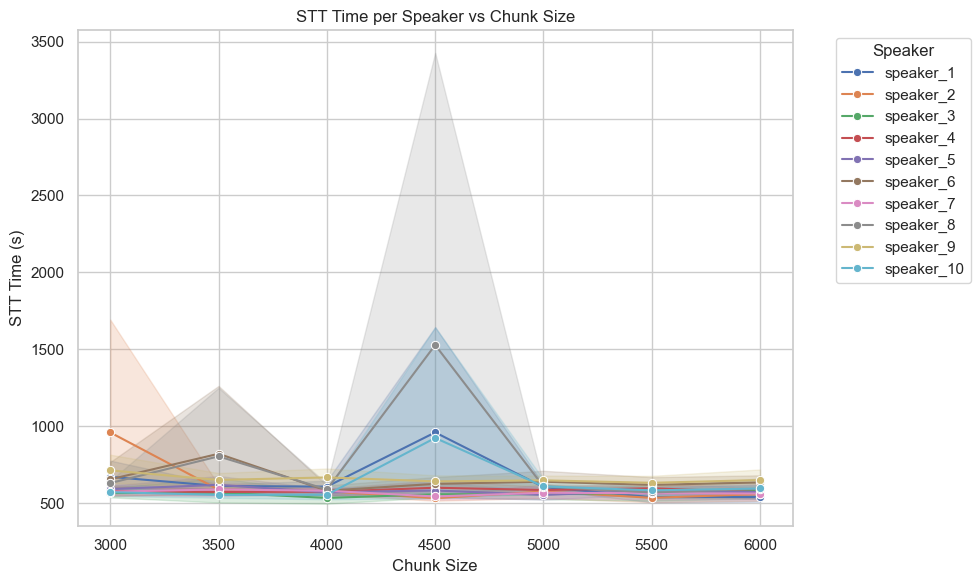

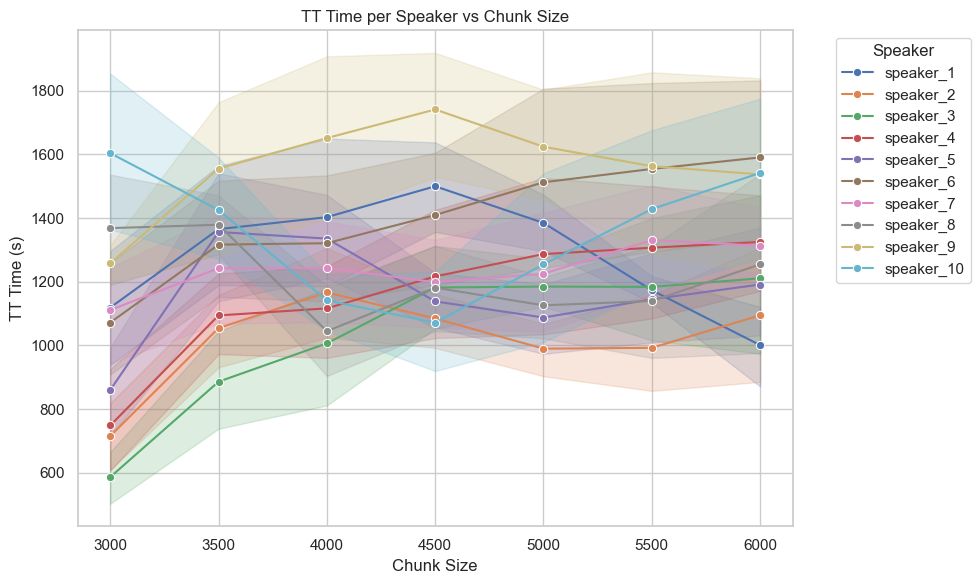

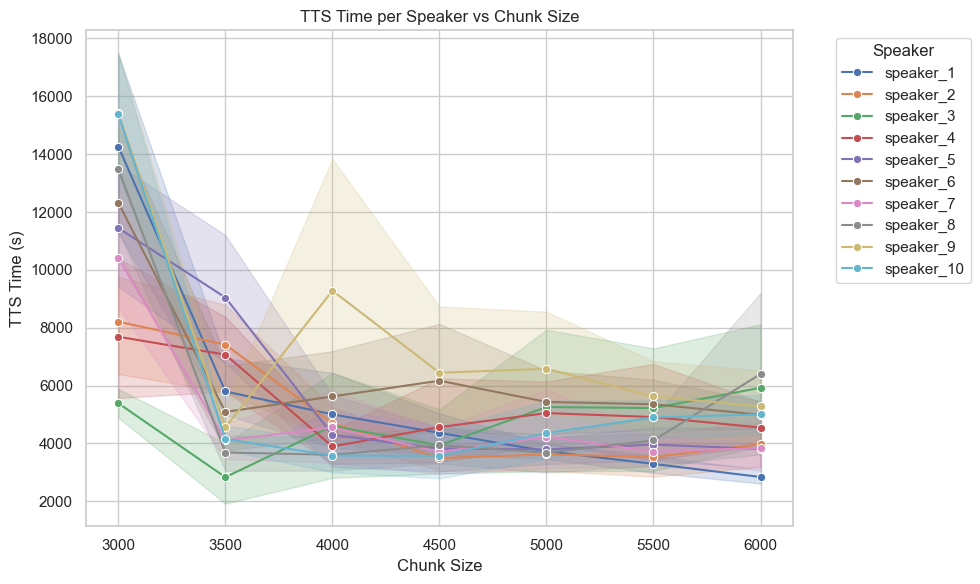

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


def explode_time_by_speaker(df, time_col, chunk_sizes):
    records = []
    for _, row in df.iterrows():
        times = row[time_col]
        speaker = row['speaker']
        for i, time in enumerate(times):
            if i < len(chunk_sizes):
                records.append({
                    'speaker': speaker,
                    'chunk_size': chunk_sizes[i],
                    'time': time
                })
    return pd.DataFrame(records)



chunk_sizes = [3000, 3500, 4000, 4500, 5000, 5500, 6000]

df_stt = explode_time_by_speaker(df, 'stt_time', chunk_sizes)
df_tt = explode_time_by_speaker(df, 'tt_time', chunk_sizes)
df_tts = explode_time_by_speaker(df, 'tts_time', chunk_sizes)


sns.set(style="whitegrid")

# STT Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_stt, x='chunk_size', y='time', hue='speaker', marker='o')
plt.title('STT Time per Speaker vs Chunk Size')
plt.ylabel('STT Time (s)')
plt.xlabel('Chunk Size')
plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# TT Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_tt, x='chunk_size', y='time', hue='speaker', marker='o')
plt.title('TT Time per Speaker vs Chunk Size')
plt.ylabel('TT Time (s)')
plt.xlabel('Chunk Size')
plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# TTS Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_tts, x='chunk_size', y='time', hue='speaker', marker='o')
plt.title('TTS Time per Speaker vs Chunk Size')
plt.ylabel('TTS Time (s)')
plt.xlabel('Chunk Size')
plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




## Plot for each STT, TT, TTS showing average

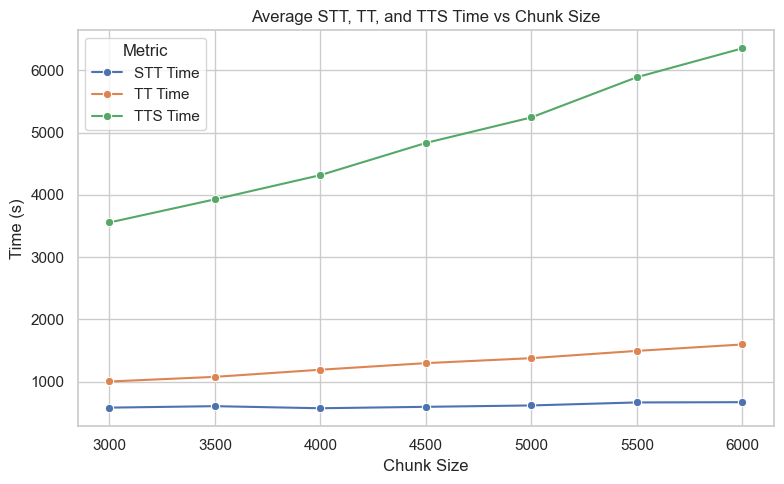

In [19]:
# df['stt_time'] = df['stt_time'].apply(ast.literal_eval)
# df['tt_time'] = df['tt_time'].apply(ast.literal_eval)
# df['tts_time'] = df['tts_time'].apply(ast.literal_eval)


df['avg_stt_time'] = df['stt_time'].apply(lambda x: sum(x)/len(x))
df['avg_tt_time'] = df['tt_time'].apply(lambda x: sum(x)/len(x))
df['avg_tts_time'] = df['tts_time'].apply(lambda x: sum(x)/len(x))


grouped = df.groupby('chunk_size')[['avg_stt_time', 'avg_tt_time', 'avg_tts_time']].mean().reset_index()



# Set seaborn style
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))


# Plot each line separately
sns.lineplot(data=grouped, x='chunk_size', y='avg_stt_time', marker='o', label='STT Time')
sns.lineplot(data=grouped, x='chunk_size', y='avg_tt_time', marker='o', label='TT Time')
sns.lineplot(data=grouped, x='chunk_size', y='avg_tts_time', marker='o', label='TTS Time')

# Set titles and labels
plt.title('Average STT, TT, and TTS Time vs Chunk Size')
plt.ylabel('Time (s)')
plt.xlabel('Chunk Size')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
